In [21]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns

In [1]:
# Experiment 1 - Understanding what cost functions is :

In [14]:
def train_lr(x,y,w,b): 

    predictions = [] # A list to store the predictions from equation of Linear Regression

    # Loop around to get predictions
    for value in x:
        predictions.append(w*value+b)

    print(f'Predictions : {predictions}')

    loss = [x - y for x,y in zip(y,predictions)]
    print(f'Loss across epochs : {loss}')

    print(f'Total Loss : {sum(loss)}')

In [15]:
# Suppose we have arrays for X and y respectively
X = [1,2,3,4,5] # Independent Variable
y = [3,5,7,9,11] # Dependent Variable

# For this case we assume our w and b to be :
w = 1
b = 1

train_lr(X,y,w,b)

Predictions : [2, 3, 4, 5, 6]
Loss across epochs : [1, 2, 3, 4, 5]
Total Loss : 15


In [44]:
# TO try different weights and analyze I tweak the function a bit

X = [1,2,3,4,5] # Independent Variable
y = [3,5,7,9,11] # Dependent Variable

b = 1

def train_lr(X,y,w,b): 

    predictions = [] # A list to store the predictions from equation of Linear Regression

    # Loop around to get predictions
    for value in X:
        predictions.append(w*value+b)

    loss = [x - y_pred for x,y_pred in zip(y,predictions)]
    mae = [abs(x - y_pred) for x,y_pred in zip(y,predictions)]
    mse = [(x - y_pred)**2 for x,y_pred in zip(y,predictions)]

    # Return the true Mean of these metrics
    n = len(y)
    return sum(loss)/n, sum(mae)/n, sum(mse)/n

# Now we loop this with different weight values 

cost_ = []
mae_ = []
mse_ = []

weights_ = [weight for weight in np.arange(-5.0, 5.0, 0.2)]
for weight in weights_:

    i,j,k = train_lr(X,y,weight,b)

    cost_.append(i)
    mae_.append(j)
    mse_.append(k)


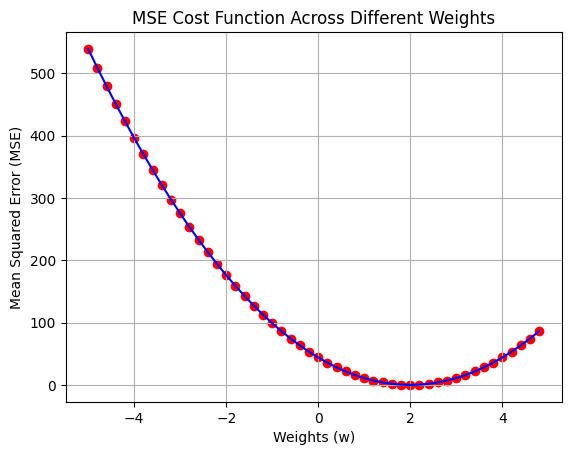

In [45]:
# Now let's visualize weights vs cost
plt.plot(weights_, mse_, color='blue')
plt.scatter(weights_, mse_, color='red')
plt.xlabel('Weights (w)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('MSE Cost Function Across Different Weights')
plt.grid(True)
plt.show()

In [46]:
# Now we do numerical Gradient Descent

# Initial parameters
w = -4.0  # Intentional terrible starting weight
b = 0.0   # Intentional terrible starting bias
alpha = 0.05  # Learning rate
epochs = 100
h = 0.00001  # Tiny step for calculating numerical gradient

print("Starting Numerical Gradient Descent...\n")

for epoch in range(epochs):
    # 1. Get current base MSE cost
    _, _, current_mse = train_lr(X, y, w, b)
    
    # 2. Approximate slope for weight (w)
    _, _, mse_w_nudged = train_lr(X, y, w + h, b)
    slope_w = (mse_w_nudged - current_mse) / h
    
    # 3. Approximate slope for bias (b)
    _, _, mse_b_nudged = train_lr(X, y, w, b + h)
    slope_b = (mse_b_nudged - current_mse) / h
    
    # 4. Update parameters against the gradient
    w = w - (alpha * slope_w)
    b = b - (alpha * slope_b)
    
    # Track progress every 10 steps
    if epoch % 10 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch:2d} | MSE: {current_mse:7.4f} | w: {w:5.2f} | b: {b:5.2f}")

print(f"\nFinal learned equation: y = {w:.2f}x + {b:.2f}")


Starting Numerical Gradient Descent...

Epoch  0 | MSE: 433.0000 | w:  2.90 | b:  1.90
Epoch 10 | MSE:  0.0489 | w:  1.86 | b:  1.51
Epoch 20 | MSE:  0.0348 | w:  1.88 | b:  1.43
Epoch 30 | MSE:  0.0247 | w:  1.90 | b:  1.36
Epoch 40 | MSE:  0.0176 | w:  1.92 | b:  1.31
Epoch 50 | MSE:  0.0125 | w:  1.93 | b:  1.26
Epoch 60 | MSE:  0.0089 | w:  1.94 | b:  1.22
Epoch 70 | MSE:  0.0063 | w:  1.95 | b:  1.18
Epoch 80 | MSE:  0.0045 | w:  1.96 | b:  1.15
Epoch 90 | MSE:  0.0032 | w:  1.96 | b:  1.13
Epoch 99 | MSE:  0.0024 | w:  1.97 | b:  1.11

Final learned equation: y = 1.97x + 1.11
